# Trabajo Práctico AA1 - Clasificación

In [1]:
#%%capture
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# manipulación, visualización y modelado.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# separación de datos, modelos y métricas.
from sklearn.base import clone
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, roc_auc_score, auc
import warnings
warnings.simplefilter('ignore')
import optuna
import tensorflow as tf

# preprocesamiento fold-local.
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from weather_preprocessing import (
    CATEGORICAL_COLUMNS,
    KNN_COLUMNS,
    MEDIAN_COLUMNS,
    MODE_COLUMNS,
    NUMERIC_COLUMNS,
    build_weather_preprocessor,
    prepare_pycaret_frame,
)
import joblib
# geolocalización y visualización de ubicaciones.
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from folium import Map, Marker, Icon
from sklearn.cluster import KMeans
from pycaret.classification import *


## Ítem 1: Análisis descriptivo

In [3]:
# Cargamos el dataset
df_original = pd.read_csv("./content/weatherAUS_2026C1.csv")
df_original.head()

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


In [4]:
#copiamos el dataset para mantener el original
df = df_original.copy()

In [5]:
# revisamos las columnas
df.columns

Index(['Unnamed: 0', 'Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall',
       'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am',
       'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow', 'RainfallTomorrow'],
      dtype='object')

In [6]:
# revisamos cantidad de filas y columnas
df.shape

(145412, 25)

In [7]:
# revisamos tipos de datos y valores no nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        145412 non-null  int64  
 1   Date              145412 non-null  object 
 2   Location          145412 non-null  object 
 3   MinTemp           143928 non-null  float64
 4   MaxTemp           144159 non-null  float64
 5   Rainfall          142152 non-null  float64
 6   Evaporation       82658 non-null   float64
 7   Sunshine          75616 non-null   float64
 8   WindGustDir       135096 non-null  object 
 9   WindGustSpeed     135159 non-null  float64
 10  WindDir9am        134850 non-null  object 
 11  WindDir3pm        141186 non-null  object 
 12  WindSpeed9am      143645 non-null  float64
 13  WindSpeed3pm      142351 non-null  float64
 14  Humidity9am       142759 non-null  float64
 15  Humidity3pm       140907 non-null  float64
 16  Pressure9am       13

### Descripción de variables

- Date: fecha de la observación.
- Location: ciudad o estación meteorológica donde se tomó la observación.
- MinTemp: temperatura mínima registrada durante el día.
- MaxTemp: temperatura máxima registrada durante el día.
- Rainfall: cantidad de lluvia registrada durante el día.
- Evaporation: evaporación registrada.
- Sunshine: cantidad de horas de sol.
- WindGustDir: dirección de la ráfaga de viento más fuerte.
- WindGustSpeed: velocidad de la ráfaga de viento más fuerte.
- WindDir9am: dirección del viento a las 9am.
- WindDir3pm: dirección del viento a las 3pm.
- WindSpeed9am: velocidad del viento a las 9am.
- WindSpeed3pm: velocidad del viento a las 3pm.
- Humidity9am: humedad a las 9am.
- Humidity3pm: humedad a las 3pm.
- Pressure9am: presión atmosférica a las 9am.
- Pressure3pm: presión atmosférica a las 3pm.
- Cloud9am: nubosidad a las 9am.
- Cloud3pm: nubosidad a las 3pm.
- Temp9am: temperatura a las 9am.
- Temp3pm: temperatura a las 3pm.
- RainToday: indica si llovió durante el día actual.
- RainTomorrow: variable objetivo; indica si llovió al día siguiente.
- RainfallTomorrow: Cantidad de lluvia al día siguiente

In [8]:
df.isnull().sum()

Unnamed: 0              0
Date                    0
Location                0
MinTemp              1484
MaxTemp              1253
Rainfall             3260
Evaporation         62754
Sunshine            69796
WindGustDir         10316
WindGustSpeed       10253
WindDir9am          10562
WindDir3pm           4226
WindSpeed9am         1767
WindSpeed3pm         3061
Humidity9am          2653
Humidity3pm          4505
Pressure9am         15061
Pressure3pm         15024
Cloud9am            55870
Cloud3pm            59336
Temp9am              1766
Temp3pm              3607
RainToday            3260
RainTomorrow         3259
RainfallTomorrow     3259
dtype: int64

Se detectan valores faltantes en varias columnas, por lo que será necesario tratarlo según el caso.

In [9]:
df = df.drop(columns=["Unnamed: 0"])

La columna "Unnamed: 0" parece ser un índice guardado en el archivo CSV, por lo que no representa una variable climática útil para la predicción. Por este motivo se elimina del análisis.

In [10]:
df = df.drop(columns=["RainfallTomorrow"])

In [11]:
# verificamos que hayan sido eliminadas
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

La columna "RainfallTomorrow" no se utiliza como variable predictora porque contiene información asociada al día siguiente. Como el objetivo es predecir a las 23:59 hs si al día siguiente lloverá o no, esta información no estaría disponible al momento de realizar la predicción. Usarla produciría fuga de datos.

### EDA

### Locations

In [12]:
def CamelCase(cadena: str) -> str:
  """
  Funcion para modificar el nombre de las variables porque sino tira error por como esta hecha.
  """
  resultado = ""
  for i, caracter in enumerate(cadena):
    #print(i,caracter)
    if i > 0 and caracter.isupper() and cadena[i-1].islower():
      resultado += " "
    resultado += caracter
  return resultado

In [13]:
ciudades = df['Location'].unique()
geolocator = Nominatim(user_agent="climate_region_clustering", timeout=10)
geocode = RateLimiter(
    geolocator.geocode,
    min_delay_seconds=1.2,
    max_retries=3,
    error_wait_seconds=5,
    swallow_exceptions=True,
    return_value_on_exception=None
)
# Obtener coordenadas
coords = []
contador = 0
print("Obteniendo coordenadas de las ciudades...")
for ciudad in ciudades:
  location = geocode(f"{CamelCase(ciudad)}, Australia")
  #print(location)
  if location:
    lat = location.latitude
    lon = location.longitude
    coords.append((ciudad, lat, lon))
    contador += 1
  else:
    print(f"No se encontró: {ciudad}")
    coords.append((ciudad, None, None))

df_coords = pd.DataFrame(coords, columns=["Location", "Latitude", "Longitude"])
print(f"Se cargaron correctamente {contador} ciudades.")

Obteniendo coordenadas de las ciudades...
Se cargaron correctamente 49 ciudades.


In [14]:
df_coords.head(54)

,Location,Latitude,Longitude
0,Albury,-36.073773,146.913526
1,BadgerysCreek,-33.883145,150.742466
2,Cobar,-31.966663,145.304505
3,CoffsHarbour,-30.298600,153.109412
4,Moree,-29.461720,149.840715
5,Newcastle,-32.919295,151.779535
6,NorahHead,-33.281667,151.567778
7,NorfolkIsland,-29.032804,167.948314
8,Penrith,-33.751195,150.694171
9,Richmond,-37.807450,144.990721


In [15]:
map = Map(location=[-25.0, 133.0], zoom_start=4)
for _, row in df_coords.iterrows():
  Marker(location=[row['Latitude'], row['Longitude']], popup=row['Location'], icon=Icon()).add_to(map)
map

Ahora que tenemos las coordenadas y las ciudades ubicadas, las agrupamos en Regiones

In [16]:
# Aplicar KMeans sobre latitud y longitud
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
df_coords["Region"] = kmeans.fit_predict(df_coords[["Latitude", "Longitude"]])

  File "c:\Valentin\TUIA\Aprendisaje Automatico I\AA1-TUIA-Dimenna-Jacob-Taborda\venv_tp\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\valen\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\valen\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\valen\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


In [17]:
colores = ['red', 'pink', 'green', 'purple', 'orange', 'darkred', 'darkgreen', 'darkblue', 'black', 'blue']

map = Map(location=[-25.0, 133.0], zoom_start=4)
for _, row in df_coords.iterrows():
  # Elegir el color según el cluster
  color = colores[row['Region'] % len(colores)]
  Marker(location=[row['Latitude'], row['Longitude']], popup=f"{row['Location']} (Cluster {row['Region']})", icon=Icon(color=color)).add_to(map)
map

In [18]:
# Agregar Region al df original
df = df.merge(df_coords[['Location', 'Region']], on='Location', how='left')

In [19]:
df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Region
0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,W,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,9
1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,NNW,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,9
2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,W,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,9
3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,SE,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,9
4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,ENE,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145407,2017-06-20,Uluru,2.6,22.0,0.0,NaN,NaN,E,29.0,ESE,...,26.5,1024.8,1021.2,NaN,NaN,10.1,21.6,No,No,8
145408,2017-06-21,Uluru,3.1,23.2,0.0,NaN,NaN,E,31.0,SE,...,24.7,1024.3,1020.5,NaN,NaN,11.1,21.5,No,No,8
145409,2017-06-22,Uluru,3.6,26.0,0.0,NaN,NaN,NNW,21.0,SE,...,21.4,1023.3,1018.4,NaN,NaN,11.8,24.5,No,No,8
145410,2017-06-23,Uluru,4.8,27.4,0.0,NaN,NaN,N,39.0,SE,...,23.7,1021.0,1016.0,NaN,NaN,12.0,26.9,No,No,8


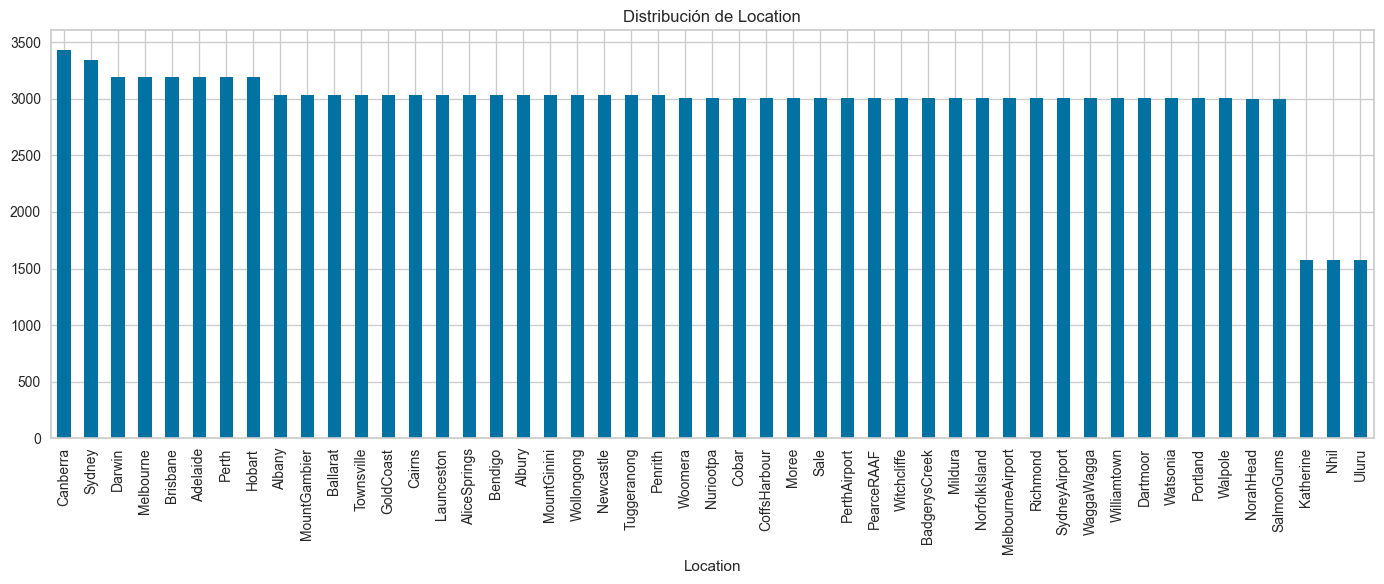

In [20]:
df['Location'].value_counts().plot(kind='bar', figsize=(14, 6))
plt.title("Distribución de Location")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# Location se conserva en los datos crudos del modelo.
# La Region calculada arriba se usa solo para EDA; el modelo ajusta su propio
# KMeans dentro del subtrain de cada fold.


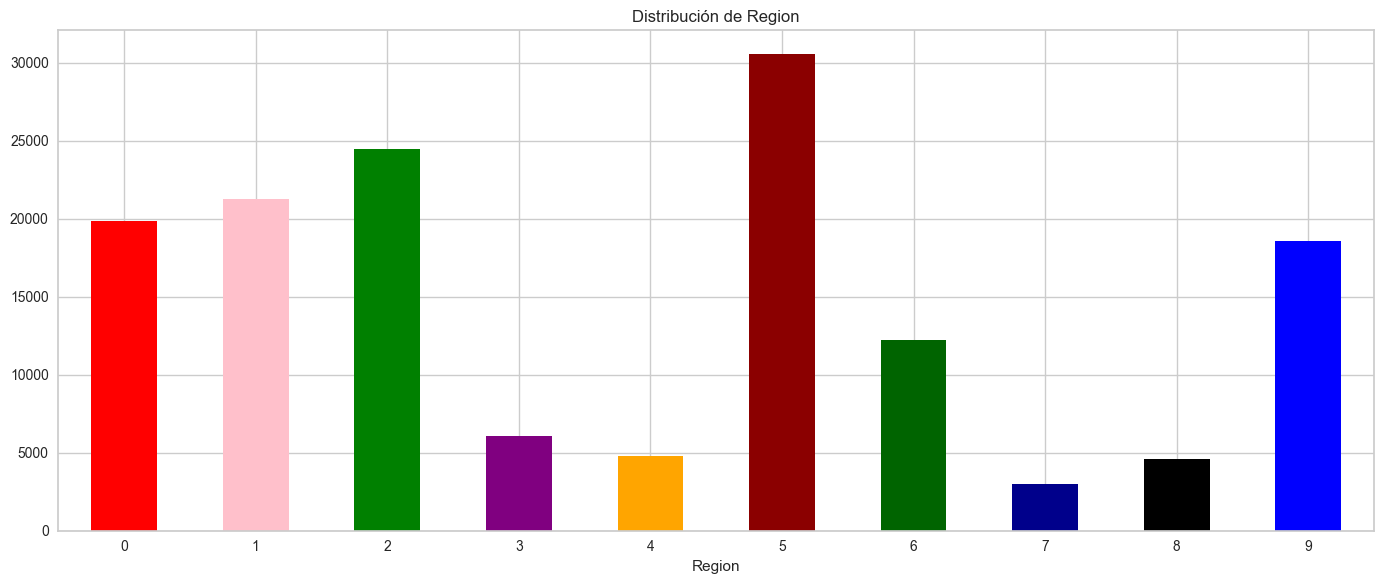

In [22]:
df['Region'].value_counts().sort_index().plot(kind='bar', figsize=(14, 6), color=colores)
plt.title("Distribución de Region")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
# revisamos los valores de la variable objetivo
df["RainTomorrow"].value_counts(dropna=False)

RainTomorrow
No     110281
Yes     31872
NaN      3259
Name: count, dtype: int64

In [24]:
# Calculamos la proporción de cada clase
df["RainTomorrow"].value_counts(normalize=True, dropna=False)

RainTomorrow
No     0.758404
Yes    0.219184
NaN    0.022412
Name: proportion, dtype: float64

In [25]:
# eliminamos filas donde la variable objetivo no tiene valor
df = df.dropna(subset=["RainTomorrow"])
# verificamos
df["RainTomorrow"].value_counts(dropna=False)

RainTomorrow
No     110281
Yes     31872
Name: count, dtype: int64

In [26]:
df_nuevo = df.copy()

In [ ]:
# Separamos variables predictoras y objetivo.
# Region fue ajustada sobre todas las ubicaciones para EDA y no entra al modelo.
# El preprocesador fold-local parte de Date y Location crudas.
X = df_nuevo.drop(columns=["RainTomorrow", "Region"])
y = df_nuevo["RainTomorrow"]


In [ ]:
# Protocolo de evaluacion primario: split aleatorio estratificado.
# El test final queda reservado y no participa en seleccion de modelos,
# hiperparametros, features ni umbrales.
RANDOM_STATE = 42
FINAL_TEST_SIZE = 0.20
VALIDATION_SIZE_WITHIN_DEVELOPMENT = 0.20

EVALUATION_PROTOCOL = {
    "primary": {
        "name": "random_stratified",
        "purpose": "generalizacion entre observaciones meteorologicas historicas similares",
        "random_state": RANDOM_STATE,
        "development_fraction": 1 - FINAL_TEST_SIZE,
        "final_test_fraction": FINAL_TEST_SIZE,
        "validation_fraction_within_development": VALIDATION_SIZE_WITHIN_DEVELOPMENT,
    },
    "secondary": {
        "name": "temporal_robustness",
        "status": "implemented",
        "approach": "expanding_window_5fold",
        "decision_impact": "none",
        "threshold_source": "priority_3_oof_selection",
        "purpose": "comparar robustez frente a observaciones cronologicamente posteriores",
    },
    "final_test_policy": {
        "status": "complete",
        "evaluation_count": 1,
        "result_artifact": "artifacts/final_test_metrics.json",
        "allowed": ["single_final_evaluation_after_model_and_threshold_are_frozen"],
        "forbidden": [
            "model_selection",
            "hyperparameter_selection",
            "threshold_selection",
            "feature_selection",
        ],
    },
}

# 80% desarrollo / 20% test final.
X_development, X_test_final_raw, y_development, y_test_final = train_test_split(
    X,
    y,
    test_size=FINAL_TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

# Dentro de desarrollo: 80% entrenamiento / 20% validacion.
# Equivale aproximadamente a 64%/16%/20% sobre el total.
X_train, X_validation, y_train, y_validation = train_test_split(
    X_development,
    y_development,
    test_size=VALIDATION_SIZE_WITHIN_DEVELOPMENT,
    random_state=RANDOM_STATE,
    stratify=y_development,
)

# Manifiesto reproducible: una fila del CSV solo puede pertenecer a un split.
random_split_manifest = pd.concat([
    pd.Series("train", index=X_train.index, name="split"),
    pd.Series("validation", index=X_validation.index, name="split"),
    pd.Series("test_final", index=X_test_final_raw.index, name="split"),
]).sort_index()

random_split_manifest.to_csv("random_split_manifest.csv", index_label="row_index")

In [ ]:
df_train = pd.concat([X_train, y_train], axis=1)
df_validation = pd.concat([X_validation, y_validation], axis=1)

# El test final se conserva crudo hasta que el modelo y el umbral queden congelados.
df_test_final_raw = X_test_final_raw.copy()

In [ ]:
# Comprobaciones estructurales del protocolo.
assert X_train.index.is_unique
assert X_validation.index.is_unique
assert X_test_final_raw.index.is_unique

assert set(X_train.index).isdisjoint(X_validation.index)
assert set(X_train.index).isdisjoint(X_test_final_raw.index)
assert set(X_validation.index).isdisjoint(X_test_final_raw.index)

assert len(random_split_manifest) == len(X)
assert random_split_manifest.index.is_unique
assert set(random_split_manifest.index) == set(X.index)

print("Train:", len(X_train))
print("Validation:", len(X_validation))
print("Test final aislado:", len(X_test_final_raw))

In [ ]:
# Graficamos la distribución de la variable objetivo
sns.countplot(data=df_train,x="RainTomorrow", order=["Yes", "No"])
plt.title("Distribución de RainTomorrow")
plt.xlabel("Llueve mañana")
plt.ylabel("Cantidad de observaciones")
plt.show()

La variable objetivo del problema es "RainTomorrow", que indica si al día siguiente llovió o no. En distribución observamos que la clase "No" aparece con mucha mayor frecuencia que la clase "Yes". Por ende el dataset está desbalanceado, por este motivo, además de accuracy, será necesario observar métricas como precision, recall y F1-score, especialmente para la clase "Yes". Sino el modelo puede no aprender a detectar bien los dias que si llueve

Las filas con valores faltantes en "RainTomorrow" se eliminan porque esta columna es la variable objetivo. Si no se conoce si al día siguiente llovió o no, esa observación no puede utilizarse para entrenar ni evaluar un modelo supervisado.

In [ ]:
df_train.dtypes

In [ ]:
# calculamos cantidad y porcentaje de valores faltantes por columna
faltantes = pd.DataFrame({
    "cantidad_faltantes": df_train.isna().sum(),
    "porcentaje_faltantes": df_train.isna().mean() * 100
})

faltantes = faltantes.sort_values(by="porcentaje_faltantes", ascending=False)

faltantes

Observamos que algunas variables presentan un porcentaje alto de valores faltantes, por este motivo no se eliminan filas completas con valores faltantes, ya que eso implicaría perder una gran cantidad de observaciones. Se decide conservar inicialmente las variables y realizar la imputación más adelante después de separar los datos de desarrollo en entrenamiento y validación.

In [ ]:
# identificamos variables numéricas y categóricas
columnas_numericas = df_train.select_dtypes(include=["int64", "float64"]).columns
columnas_categoricas = df_train.select_dtypes(include=["object","int32"]).columns

print("Variables numéricas:")
print(columnas_numericas)

print("\nVariables categóricas:")
print(columnas_categoricas)

In [ ]:
# obtenemos medidas descriptivas de las variables numéricas
df_train[columnas_numericas].describe().T

Calculamos las medidas para las variables numéricas para detectar diferencias de escala entre variables

In [ ]:
# obtenemos un resumen de las variables categóricas.
df_train[columnas_categoricas].describe().T

En este caso interesa observar cuántas categorías distintas tiene cada variable y cuál es el valor más frecuente

### Histogramas

In [ ]:
df_train.columns

In [ ]:
len(df_train.columns)

In [ ]:
plt.figure(figsize=(16, 10))
for i, var in enumerate(columnas_numericas, 1):
    plt.subplot(4, 4, i)
    sns.histplot(df_train[var], kde=True, bins=30)
    plt.title(f"Distribución de {var}")
    plt.xlabel("")

In [ ]:
# graficamos histogramas para observar la distribución de las variables numéricas.
df_train[columnas_numericas].hist(figsize=(15, 12), bins=30)
plt.suptitle("Distribución de variables numéricas")
plt.tight_layout()
plt.show()

Graficamos histogramas de las variables numéricas para observar su distribución. Observamos que las variables no se encuentran en la misma escala, por ejemplo, temperatura, presión, humedad, velocidad del viento y lluvia tienen unidades y rangos distintos. Por este motivo, más adelante será necesario aplicar escalado

### Boxplots

In [ ]:
# Graficamos boxplots individuales para todas las variables numéricas.
for columna in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_train, x=columna)
    plt.title(f"Boxplot de {columna}")
    plt.xlabel(columna)
    plt.show()

In [ ]:
# calculamos outliers por variable numérica usando el criterio del rango intercuartílico
resumen_outliers = []

for columna in columnas_numericas:
    q1 = df_train[columna].quantile(0.25)
    q3 = df_train[columna].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    cantidad_outliers = ((df_train[columna] < limite_inferior) | (df_train[columna] > limite_superior)).sum()

    porcentaje_outliers = cantidad_outliers / df_train[columna].notna().sum() * 100

    resumen_outliers.append({
        "variable": columna,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "cantidad_outliers": cantidad_outliers,
        "porcentaje_outliers": porcentaje_outliers
    })

resumen_outliers = pd.DataFrame(resumen_outliers)
resumen_outliers.sort_values(by="porcentaje_outliers", ascending=False)

In [ ]:
# verificamos si existen valores negativos en variables que no deberían ser negativas
variables_no_negativas = ["Rainfall", "Evaporation", "Sunshine","WindGustSpeed", "WindSpeed9am", "WindSpeed3pm","Humidity9am", "Humidity3pm","Pressure9am", "Pressure3pm", "Cloud9am", "Cloud3pm"]

valores_negativos = {}

for columna in variables_no_negativas:
    cantidad_negativos = (df_train[columna] < 0).sum()
    valores_negativos[columna] = cantidad_negativos

pd.Series(valores_negativos).sort_values(ascending=False)

In [ ]:
# observamos los valores más frecuentes de Rainfall
df_train["Rainfall"].value_counts().head(20)

Analizamos posibles valores extremos utilizando el criterio del rango intercuartílico (IQR). Este criterio marca como posibles outliers los valores menores a Q1 - 1.5 * IQR o mayores a Q3 + 1.5 * IQR. Observamos también que una gran parte de las observaciones tiene lluvia igual o cercana a 0 mm. Esto hace que el rango intercuartílico sea bajo y que valores de lluvia mayores a 2 mm sean marcados como outliers. Estos valores no necesariamente representan errores, sino que pueden ser días con mayor cantidad de lluvia.

### Matriz de correlación

In [ ]:
# calculamos la matriz de correlación entre variables numéricas
correlacion = df_train[columnas_numericas].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlacion, cmap="coolwarm", center=0, annot=True)
plt.title("Matriz de correlación entre variables numéricas")
plt.xticks(rotation=45)
plt.show()

Se identifican correlaciones positivas fuertes entre variables relacionadas con la temperatura, como "MaxTemp" y "Temp3pm", y entre variables de presión, como "Pressure9am" y "Pressure3pm", también se observan correlaciones negativas entre "Sunshine" y variables como "Cloud9am", "Cloud3pm" y "Humidity3pm", lo cual es coherente con el clima, a mayor nubosidad o humedad o menor cantidad de horas de sol.
Esta matriz se utiliza como análisis exploratorio. No se eliminan variables automáticamente por correlación en esta etapa

In [ ]:
df_train[columnas_categoricas].nunique()

In [ ]:
# Date -> Month se calcula en copias destinadas exclusivamente al EDA.
# Los conjuntos de modelado permanecen crudos para que el Pipeline controle el fit.
df_train_eda = df_train.copy()
df_validation_eda = df_validation.copy()
for frame_eda in (df_train_eda, df_validation_eda):
    frame_eda["Date"] = pd.to_datetime(frame_eda["Date"], errors="coerce")
    frame_eda["Month"] = frame_eda["Date"].dt.month


Cambiamos la variable mes por Season para bajar las opciones de la variable de 12 a 4 y bajar la dimensionalidad del modelo

In [ ]:
def asignar_estacion(mes):
    if mes in [12, 1, 2]:
        return "Summer"
    if mes in [3, 4, 5]:
        return "Autumn"
    if mes in [6, 7, 8]:
        return "Winter"
    if mes in [9, 10, 11]:
        return "Spring"
    return None

for frame_eda in (df_train_eda, df_validation_eda):
    frame_eda["Season"] = frame_eda["Month"].apply(asignar_estacion)


In [ ]:
# X_train/X_validation conservan Date y Location sin transformar.
# y_train/y_validation mantienen exactamente los índices creados en el split.
assert {"Date", "Location"}.issubset(X_train.columns)
assert X_train.index.equals(y_train.index)
assert X_validation.index.equals(y_validation.index)


Vemos que Location tiene demasiadas categorias en comparacion con las demas porque son ciudades, podemos reducirla agrupando por regiones mas grandes en vez de por ciudad

La columna "Date" se convierte a formato fecha y se utiliza para extraer el mes de la observación, lo que permite conservar información  sobre estaciones, ya que la probabilidad de lluvia puede variar según la época del año. Luego se elimina la fecha completa, porque codificar cada día como una categoría distinta generaría muchas columnas y no aportaría una representación simple para el modelo.

In [ ]:
# codificamos la variable objetivo: No = 0, Yes = 1.
y_train = y_train.map({"No": 0, "Yes": 1})
y_validation = y_validation.map({"No": 0, "Yes": 1})

In [ ]:
y_development_encoded = pd.concat([y_train, y_validation])

La variable objetivo se codifica como variable binaria donde "No" se representa con 0 y "Yes" con 1 para que la clase positiva corresponda a los días en los que si llueve

In [ ]:
# Esquema de salida del preprocesador (después de Date/Location -> Season/Region).
columnas_numericas = list(NUMERIC_COLUMNS)
columnas_categoricas = list(CATEGORICAL_COLUMNS)

print("Variables numéricas:")
print(columnas_numericas)
print("\nVariables categóricas:")
print(columnas_categoricas)


Se vuelven a identificar las columnas numéricas y categóricas únicamente dentro de "X" para no incluir la variable objetivo dentro de las predictoras

In [ ]:
# Verificamos proporciones solo dentro del conjunto de desarrollo.
# El target del test final no se inspecciona para tomar decisiones.
print("Proporcion en desarrollo:")
print(y_development_encoded.value_counts(normalize=True))

print("\nProporcion en entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nProporcion en validacion:")
print(y_validation.value_counts(normalize=True))

El protocolo primario conserva una separacion aleatoria estratificada porque el objetivo es aprender patrones entre observaciones meteorologicas similares aunque pertenezcan a anos distintos.

Se reserva un 20% como **test final aislado**. El 80% restante forma el conjunto de desarrollo y se divide nuevamente en entrenamiento y validacion. Toda seleccion de modelos, hiperparametros y umbrales se realiza con entrenamiento/validacion; el test final se utiliza una sola vez despues de congelar esas decisiones.

La evaluación temporal se implementa como análisis secundario de robustez mediante cinco ventanas expansivas. Reentrena únicamente clones de la configuración ya congelada y utiliza el mismo threshold OOF; sus resultados no participan en ninguna decisión del protocolo principal.

In [ ]:
# Las coordenadas son metadatos externos; KMeans sí aprende y por eso se ajusta
# dentro de WeatherFeatureTransformer para cada fold.
location_coordinates = (
    df_coords.set_index("Location")[["Latitude", "Longitude"]]
    .apply(tuple, axis=1)
    .to_dict()
)

# Este estimador no se ajusta aquí. Cada modelo recibe un clon dentro de su Pipeline.
preprocesamiento = build_weather_preprocessor(
    location_coordinates=location_coordinates,
    random_state=RANDOM_STATE,
)

# Pipeline reducido para el modelo didáctico de una sola variable.
preprocesamiento_numerico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])


### Imputacion de Datos

#### Variables Numericas

Las imputaciones por mediana de región/estación y por KNN mantienen la metodología original, pero ahora están implementadas en `WeatherFeatureTransformer`. Sus tablas, escalador e imputadores se crean en `fit`; al formar parte del `Pipeline`, `GridSearchCV` ajusta una copia independiente únicamente con el subtrain de cada fold. La validación del fold y la validación externa llaman solamente a `transform`.


In [ ]:
X_train.isnull().sum()


In [ ]:
variables_mediana = list(MEDIAN_COLUMNS)
len(variables_mediana)


In [ ]:
X_train.head()


In [ ]:
# No se calculan medianas fuera del Pipeline.
print("Medianas Region/Season: fit fold-local dentro de WeatherFeatureTransformer")


In [ ]:
X_train.isnull().sum()


In [ ]:
X_validation.isnull().sum()


#### KNN Imputer

##### Escalado de Datos

Ya que KNN es un método basado en distancias, es necesario escalar los datos antes de utilizarlo para imputar. Sino las variables con valores grandes podrían dominar la distancia y afectar la imputacion

In [ ]:
# El StandardScaler usado por KNN y el escalado final se ajustan dentro
# del preprocesador clonado por cada fold; aquí no se ejecuta ningún fit.
print("Escalado: fit fold-local dentro del Pipeline")


##### KNN

In [ ]:
# Variables imputadas con KNN por región y estación.
variables_knn = list(KNN_COLUMNS)


In [ ]:
# No se ajustan KNNImputer globales ni por grupo fuera del Pipeline.
print("KNNImputer: fit fold-local dentro de WeatherFeatureTransformer")


In [ ]:
X_train.isnull().sum()


In [ ]:
X_train.head()


In [ ]:
# La inspección antes/después se realizará al reejecutar con un
# preprocesador ajustado para análisis, sin reutilizarlo en validación cruzada.


In [ ]:
X_train.head()


In [ ]:
print("Visualización de imputaciones pendiente de la reejecución del protocolo fold-local")


El `Pipeline` completo contiene la ingeniería meteorológica, las imputaciones, la codificación one-hot y el escalado. No se comparte ningún objeto ajustado entre folds: scikit-learn clona el estimador y `fit` recibe solo los índices del subtrain correspondiente.


#### Variables categoricas

In [ ]:
variables_categoricas_imputar = list(MODE_COLUMNS)
print("Modas Region/Season: fit fold-local dentro de WeatherFeatureTransformer")


In [ ]:
print(X_train.isnull().sum())

## Ítem 2: Regresión logística

In [ ]:
round(y_train.value_counts(normalize=True) * 100, 2)
#round(y_validation.value_counts(normalize=True) * 100, 2)

Como ya habiamos visto el dataset esta desbalanceado por lo que usaremos class_weight = balanced para pque asigne un peso mayor a la clase minoritaria

In [ ]:
f1_comparacion_modelos = {}
accuracy_comparacion_modelos = {}
recall_comparacion_modelos = {}

In [ ]:
# Pipeline completo: el fit de toda transformación aprendida recibe solo train.
modelo_logistico = Pipeline(steps=[
    ("preprocesamiento", clone(preprocesamiento)),
    ("clasificador", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight="balanced",
    )),
])


In [ ]:
# Dataframe con el que entrenaremos al modelo
X_train

In [ ]:
# entrenamos el modelo utilizando el conjunto de entrenamiento
modelo_logistico.fit(X_train, y_train)

In [ ]:
# obtenemos las predicciones de clase sobre el conjunto de validacion
y_pred_logistico = modelo_logistico.predict(X_validation)

In [ ]:
# obtenemos las probabilidades de pertenecer a la clase positiva
y_proba_logistico = modelo_logistico.predict_proba(X_validation)[:, 1]

In [ ]:
# observamos las primeras predicciones de clase
y_pred_logistico[:10]

In [ ]:
# observamos las primeras probabilidades estimadas de lluvia
y_proba_logistico[:10]

In [ ]:
y_validation[:10]

In [ ]:
# calculamos métricas principales para evaluar el modelo de regresión logística
accuracy_logistico = accuracy_score(y_validation, y_pred_logistico)
precision_logistico = precision_score(y_validation, y_pred_logistico)
recall_logistico = recall_score(y_validation, y_pred_logistico)
f1_logistico = f1_score(y_validation, y_pred_logistico)
auc_logistico = roc_auc_score(y_validation, y_proba_logistico)

print("Accuracy:", accuracy_logistico)
print("Precision:", precision_logistico)
print("Recall:", recall_logistico)
print("F1-score:", f1_logistico)
print("ROC-AUC:", auc_logistico)

Se calculan distintas métricas porque el dataset está desbalanceado. En este caso, accuracy por si sola puede ser insuficiente, ya que un modelo podría acertar muchos casos de la clase mayoritaria (No) y aun así detectar mal los casos de lluvia (Yes). Por este motivo se analizan también precision, recall, F1-score y ROC-AUC. La clase positiva corresponde a "RainTomorrow = Yes", es decir, los días en los que sí llueve al día siguiente.

Con el umbral por defecto de 0.5, si la probabilidad es mayor o igual a 0.5 el modelo predice lluvia, si es menor, predice que no llueve. Con este umbral el modelo obtuvo una accuracy de 0.847, pero el recall fue de 0.508. Esto significa que aunque acierta muchos casos en general, detecta aproximadamente la mitad de los días en los que realmente llueve.

### Matriz de confusión

In [ ]:
# graficamos la matriz de confusión para la regresión logística
cm_logistico = confusion_matrix(y_validation, y_pred_logistico)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_logistico,display_labels=["No", "Yes"])

disp.plot()
plt.title("Matriz de confusión - Regresión logística")
plt.show()

In [ ]:
# extraemos los valores de la matriz de confusión
vn, fp, fn, vp = cm_logistico.ravel()

print("Verdaderos negativos:", vn)
print("Falsos positivos:", fp)
print("Falsos negativos:", fn)
print("Verdaderos positivos:", vp)

La matriz de confusión muestra que el modelo clasifica correctamente una gran cantidad de días sin lluvia, con 20862 verdaderos negativos. También detecta 3239 días lluviosos correctamente.

Sin embargo, se observan 3135 falsos negativos, es decir días en los que realmente llovió pero el modelo predijo que no llovería. Este valor es importante porque indica que el modelo todavía pierde una cantidad considerable de casos de lluvia.

También aparecen 1195 falsos positivos que corresponden a días en los que el modelo predijo lluvia pero finalmente no llovió. En este problema, los falsos positivos representan falsas alarmas, mientras que los falsos negativos representan lluvias no detectadas.

Esta matriz confirma lo que observamos en las métricas, el modelo tiene una buena accuracy general, pero el recall de la clase "Yes" es moderado, ya que no logra detectar todos los días lluviosos.

### Curva ROC y AUC

In [ ]:
# Calculamos la curva ROC para la regresión logística.
fpr_logistico, tpr_logistico, thresholds_logistico = roc_curve(y_validation,y_proba_logistico)

plt.figure(figsize=(8, 6))
plt.plot(fpr_logistico,tpr_logistico,label=f"Regresión logística (AUC = {auc_logistico:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Regresión logística")
plt.legend()
plt.show()

 El ROC-AUC fue de 0.870 lo cual indica que las probabilidades del modelo separan bastante bien los casos de lluvia y no lluvia, por eso el problema no necesariamente está en que el modelo no sirva, sino en que el umbral 0.5 puede no ser el más conveniente si queremos detectar más días de lluvia. Bajar el umbral podría aumentar el recall para detectar más lluvias reales pero la desventaja es que también podrían aumentar los falsos positivos

### Diagnóstico histórico con umbral fijo (no participa en la selección final)

In [ ]:
# Diagnóstico descriptivo a threshold fijo. No se optimiza con validation.
# El único threshold seleccionable se obtiene luego de probabilidades OOF.
umbral_diagnostico = 0.5
print("Umbral diagnóstico fijo:", umbral_diagnostico)

In [ ]:
# Predicciones descriptivas; no alimentan la selección oficial.
y_pred_logistico_umbral = (y_proba_logistico >= umbral_diagnostico).astype(int)

print(classification_report(y_validation, y_pred_logistico_umbral))

In [ ]:
metricas_diagnosticas_umbral_fijo = {
    "f1_positive": f1_score(y_validation, y_pred_logistico_umbral, pos_label=1),
    "precision": precision_score(y_validation, y_pred_logistico_umbral, pos_label=1),
    "recall": recall_score(y_validation, y_pred_logistico_umbral, pos_label=1),
}
metricas_diagnosticas_umbral_fijo

In [ ]:
f1_comparacion_modelos
#accuracy_comparacion_modelos

Con este nuevo umbral, el recall de la clase "Yes" aumenta de aproximadamente 0.51 a 0.80. Esto significa que el modelo detecta una mayor proporción de los días en los que realmente llueve. La precision de la clase "Yes" es 0.50 y la accuracy general disminuye a 0.78, esto pasa porque al bajar el umbral el modelo clasifica más casos como lluvia, lo que reduce los falsos negativos pero aumenta los falsos positivos.

Si se prioriza no perder lluvias reales conviene un umbral menor y si se prioriza evitar falsas alarmas conviene un umbral más alto.

## Ítem 3: Implementación de modelo base

In [ ]:
# Modelo base con el mismo contrato train/transform que el resto.
modelo_base = Pipeline(steps=[
    ("preprocesamiento", clone(preprocesamiento)),
    ("clasificador", DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)),
])

modelo_base.fit(X_train, y_train)
y_pred_base = modelo_base.predict(X_validation)


In [ ]:
# calculamos métricas principales para evaluar el modelo base basado en frecuencia
accuracy_base = accuracy_score(y_validation, y_pred_base)
precision_base = precision_score(y_validation, y_pred_base, zero_division=0)
recall_base = recall_score(y_validation, y_pred_base, zero_division=0)
f1_base = f1_score(y_validation, y_pred_base, zero_division=0)
auc_base = roc_auc_score(y_validation, y_pred_base)

print("Accuracy:", accuracy_base)
print("Precision:", precision_base)
print("Recall:", recall_base)
print("F1-score:", f1_base)
print("ROC-AUC:", auc_base)

In [ ]:
f1_modelo_base_dummy = f1_score(y_validation, y_pred_base, pos_label=1)
f1_comparacion_modelos["Modelo_base_dummy"] = f1_modelo_base_dummy
accuracy_comparacion_modelos["Modelo_base_dummy"] = accuracy_score(y_validation, y_pred_base)
recall_comparacion_modelos["Modelo_base_dummy"] = recall_score(y_validation, y_pred_base, pos_label=1)

In [ ]:
#accuracy_comparacion_modelos

In [ ]:
# graficamos la matriz de confusión para la regresión logística
cm_base = confusion_matrix(y_validation, y_pred_base)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_base,display_labels=["No", "Yes"])

disp.plot()
plt.title("Matriz de confusión - Dummy Classifier")
plt.show()

In [ ]:
# extraemos los valores de la matriz de confusión
vn, fp, fn, vp = cm_base.ravel()

print("Verdaderos negativos:", vn)
print("Falsos positivos:", fp)
print("Falsos negativos:", fn)
print("Verdaderos positivos:", vp)

La matriz de confusión del modelo base muestra que el clasificador predice siempre la clase mayoritaria, es decir, No. Por eso clasifica correctamente los días sin lluvia, pero no detecta ningún caso de lluvia.
Esto confirma que la accuracy no alcanza para evaluar este problema, ya que un modelo puede obtener un valor aparentemente aceptable simplemente prediciendo siempre la clase más frecuente.

Modelo Base: si llovió hoy, llueve mañana

In [ ]:

df_rain_train = X_train[["RainToday"]].copy()
df_rain_train["RainTomorrow"] = y_train.map({0: "No", 1: "Yes"})

# eliminamos filas donde RainToday sea nulo para observar la relación de forma directa
df_rain_train = df_rain_train.dropna(subset=["RainToday"])

tabla_rain_pct = pd.crosstab(
    df_rain_train["RainToday"],
    df_rain_train["RainTomorrow"],
    normalize="index"
) * 100

tabla_rain_pct = tabla_rain_pct.reindex(columns=["No", "Yes"])
tabla_rain_pct.round(2)

In [ ]:
tabla_rain_pct.plot(kind="bar", stacked=True, figsize=(7, 5))

plt.title("Relación entre RainToday y RainTomorrow")
plt.xlabel("¿Llovió hoy?")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.legend(title="¿Llueve mañana?")
plt.show()

En este caso, vemos que:
* Cuando no llueve en el día es muy probable que al día siguiente tampoco llueva
* Para los dias que llovió, aunque se acerca un poco en su mayoria, tampoco llueve al dia siguiente

Este modelo debería superar al anterior, predice lluvia para algunos casos en lugar de simplemente predecir que no llueve

In [ ]:
# implementamos un modelo base basado en una regla simple:
# si RainToday = Yes, predecimos RainTomorrow = Yes; si RainToday = No, predecimos RainTomorrow = No

moda_raintoday_train = X_train["RainToday"].mode()[0]

y_pred_base_raintoday = (
    X_validation["RainToday"]
    .fillna(moda_raintoday_train)
    .map({"No": 0, "Yes": 1})
    .astype(int)
)

In [ ]:
# calculamos métricas principales para evaluar el modelo base basado en RainToday
accuracy_base_raintoday = accuracy_score(y_validation, y_pred_base_raintoday)
precision_base_raintoday = precision_score(y_validation, y_pred_base_raintoday, zero_division=0)
recall_base_raintoday = recall_score(y_validation, y_pred_base_raintoday, zero_division=0)
f1_base_raintoday = f1_score(y_validation, y_pred_base_raintoday, zero_division=0)
auc_base_raintoday = roc_auc_score(y_validation, y_pred_base_raintoday)

print("Accuracy:", accuracy_base_raintoday)
print("Precision:", precision_base_raintoday)
print("Recall:", recall_base_raintoday)
print("F1-score:", f1_base_raintoday)
print("ROC-AUC:", auc_base_raintoday)

In [ ]:
f1_pred_base_raintoday = f1_score(y_validation, y_pred_base_raintoday, pos_label=1)
f1_comparacion_modelos["pred_base_raintoday"] = f1_pred_base_raintoday
accuracy_comparacion_modelos["pred_base_raintoday"] = accuracy_score(y_validation, y_pred_base_raintoday)
recall_comparacion_modelos["pred_base_raintoday"] = recall_score(y_validation, y_pred_base_raintoday, pos_label=1)

El baseline basado en la variable raintoday tiene un poco menor Accuracy que la que predice "No" pero aumenta precision y recall ya que predice positivo para algunos casos.

In [ ]:
# graficamos la matriz de confusión para la regresión logística
cm_rain_today = confusion_matrix(y_validation, y_pred_base_raintoday)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rain_today,display_labels=["No", "Yes"])

disp.plot()
plt.title("Matriz de confusión - Modelo Base (RainToday)")
plt.show()

In [ ]:
# extraemos los valores de la matriz de confusión
vn, fp, fn, vp = cm_rain_today.ravel()

print("Verdaderos negativos:", vn)
print("Falsos positivos:", fp)
print("Falsos negativos:", fn)
print("Verdaderos positivos:", vp)

In [ ]:
# copiamos las variables numéricas
df_corr = df_train[columnas_numericas].copy()

# agregamos el target codificado como variable binaria
df_corr["RainTomorrow"] = y_train

# calculamos la matriz de correlación incluyendo el target
correlacion2 = df_corr.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlacion2, cmap="coolwarm", center=0, annot=True)
plt.title("Matriz de correlación entre variables numéricas y RainTomorrow")
plt.xticks(rotation=45)
plt.show()

Elegimos usar la variable Sunshine para la regresion logistica de 1 variable

In [ ]:
X_train_variable_unica = X_train[["Sunshine"]]
X_validation_unica = X_validation[["Sunshine"]]

# Incluso en este caso la mediana y el escalado se ajustan solo con train.
modelo_logistico_una_var = Pipeline(steps=[
    ("preprocesamiento", clone(preprocesamiento_numerico)),
    ("clasificador", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight="balanced",
    )),
])
modelo_logistico_una_var.fit(X_train_variable_unica, y_train)
y_pred_una_var = modelo_logistico_una_var.predict(X_validation_unica)
y_proba_logistico_una_var = modelo_logistico_una_var.predict_proba(X_validation_unica)[:, 1]


In [ ]:
# calculamos métricas principales para evaluar el modelo de regresión logística
accuracy_logistico = accuracy_score(y_validation, y_pred_una_var)
precision_logistico = precision_score(y_validation, y_pred_una_var)
recall_logistico = recall_score(y_validation, y_pred_una_var)
f1_logistico = f1_score(y_validation, y_pred_una_var)
auc_logistico = roc_auc_score(y_validation, y_proba_logistico_una_var)

print("Accuracy:", accuracy_logistico)
print("Precision:", precision_logistico)
print("Recall:", recall_logistico)
print("F1-score:", f1_logistico)
print("ROC-AUC:", auc_logistico)

In [ ]:
f1_pred_base_una_var = f1_score(y_validation, y_pred_una_var, pos_label=1)
f1_comparacion_modelos["pred_base_una_var"] = f1_pred_base_una_var
accuracy_comparacion_modelos["pred_base_una_var"] = accuracy_score(y_validation, y_pred_una_var)
recall_comparacion_modelos["pred_base_una_var"] = recall_score(y_validation, y_pred_una_var, pos_label=1)

In [ ]:
# graficamos la matriz de confusión para la regresión logística
cm_una_var = confusion_matrix(y_validation, y_pred_una_var)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_una_var,display_labels=["No", "Yes"])

disp.plot()
plt.title("Matriz de confusión - Regresión logística")
plt.show()

In [ ]:
# extraemos los valores de la matriz de confusión
vn, fp, fn, vp = cm_una_var.ravel()

print("Verdaderos negativos:", vn)
print("Falsos positivos:", fp)
print("Falsos negativos:", fn)
print("Verdaderos positivos:", vp)

La regresión logística con todas las variables supera a los modelos base porque, además de mantener una accuracy mayor, logra identificar una parte de los días con lluvia. Esto se observa especialmente en el recall y el F1-score de la clase positiva.

Por lo tanto, la regresión logística aporta valor respecto de una estrategia ingenua basada solamente en predecir siempre la clase mayoritaria, basada en el valor de una variable o la regresión logística de una sola variable.

## Ítem 4: Optimización de hiperparámetros

Optimizaremos:
* C porque controla la regularización, entonces probamos un rango amplio para  encontrar el equilibrio que mejor generalice y evitar overfitting
* class_weight, porque permite ajustar el peso de cada clase durante el entrenamiento e incluímos balanced para que el modelo no ignore la clase minoritaria (lluvia), por estar desbalanceado el dataset
  
  

In [ ]:
# Grid search: el preprocesador completo está dentro del estimador evaluado.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_params = {
    "clasificador__C": [0.01, 0.1, 1, 10, 100, 1000, 10000],
    "clasificador__class_weight": [None, "balanced"],
}

modelo_grid = Pipeline(steps=[
    ("preprocesamiento", clone(preprocesamiento)),
    ("clasificador", LogisticRegression(
        max_iter=1000,
        solver="lbfgs",
        random_state=RANDOM_STATE,
    )),
])

grid_search = GridSearchCV(
    modelo_grid,
    grid_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)
best_grid_model = grid_search.best_estimator_
grid_search_f1 = f1_score(y_validation, best_grid_model.predict(X_validation))
accuracy_grid = accuracy_score(y_validation, best_grid_model.predict(X_validation))
precision_grid = precision_score(y_validation, best_grid_model.predict(X_validation))
recall_grid = recall_score(y_validation, best_grid_model.predict(X_validation))


Utilizamos validación cruzada para obtener una mejor estimación de F1-score. Promediamos los scores sobre distintas partes (folds) del dataset. Luego aplicamos StratifiedKFold para que las clases queden proporcionadas en cada fold, así evitamos cualquier sesgo en los datos

Elegimos grid search por sobre las otras dos opciones porque el espacio de parámetros es muy pequeño (14 combinaciones) y en estos casos grid search es más eficiente y consume menos recursos para realizar la búsqueda que Optuna o Random Search

In [ ]:
print("Mejores parámetros:", grid_search.best_params_)
print("Mejor score:", grid_search.best_score_)
print("Accuracy:", accuracy_grid)
print("Precision:", precision_grid)
print("Recall:", recall_grid)
print("F1-score:", grid_search_f1)

Optimizando los hiperparámetros del modelo con grid search, logramos un F1-score de 0.62 en validacion, superando al dummy (F1 = 0) y al modelo base asumiendo que si llovió hoy, llueve mañana (F1 = 0.45)

La mejora respecto al modelo de regresión logística del item 2 (F1 = 0.59) es muy poca, lo que sugiere que ya alcanzamos el límite del modelo de regresión logística con este dataset

In [ ]:
best_grid_model

In [ ]:
preprocesamiento_grid = best_grid_model.named_steps["preprocesamiento"]
clasificador = best_grid_model.named_steps["clasificador"]


Desempaquetamos el pipeline, extrayendo preprocesador y clasificador

In [ ]:
# Este preprocesador fue reajustado por GridSearchCV sobre todo X_train después
# de elegir hiperparámetros; validación externa recibe únicamente transform.
X_train_scaled = preprocesamiento_grid.transform(X_train)
X_validation_scaled = preprocesamiento_grid.transform(X_validation)


Transformamos los datos para que Shap los reciba preprocesados como el clasificador del pipeline (pasan de df a array)

In [ ]:
feature_names = list(preprocesamiento_grid.get_feature_names_out())


Obtenemos el nombre de todas las columnas, numéricas + categóricas expandidas por OneHotEncoder

## Ítem 5: Explicabilidad de modelos mediante SHAP

In [ ]:
# Crea un objeto explainer SHAP
explainer = shap.LinearExplainer(clasificador, X_train_scaled, feature_names=feature_names)

# Calcula los valores SHAP para un conjunto de ejemplos de validación
shap_values = explainer.shap_values(X_validation_scaled)

In [ ]:
print(explainer.expected_value)

El modelo predice (sin tener en cuenta las features) que hay más probabilidad que el día siguiente a la medición no llueva

In [ ]:
shap_values.shape

In [ ]:
shap_values[0]

### Gráficas a nivel local

In [ ]:
index=0
shap.force_plot(explainer.expected_value, shap_values[index], X_validation_scaled[index],
feature_names=feature_names, matplotlib=True, figsize=(18, 4),
text_rotation=45)

Vemos que para la primer medición del set de validacion, las features empujan la predicción desde el valor base (aprox. -0.6), hasta -1.86.

Las features que indican que no va a llover mañana tienen mayor peso que las features que indican que lloverá, es poco probable que llueva el día siguiente a la medición.

El valor que obtuvimos es logit = -1.86 (logaritmo de las chances). Podemos pasarlo a probabilidad con la fórmula p(x) = 1 / (1 + e^-(logit)).  En este caso, p(x) = 0.134 (13.4% de probabilidad de lluvia el día posterior a la medición)

In [ ]:
explanation = shap.Explanation(values=shap_values[index], base_values=explainer.expected_value, feature_names=feature_names)

In [ ]:
shap.plots.waterfall(explanation, max_display=5)

Partimos de E[f(x)] = -0.612 (valor base):
* La humedad a las 3pm se inclina mucho hacia predicciones de "no lloverá mañana"
* La presión a las 9am está asociada a menor probabilidad de lluvia

* Luego, la presión a las 3pm está asociada a una mayor probabilidad de lluvia, y en menor medida otras 66 features

La predicción final es f(x) = -1.862 (13.4% de probabilidad de lluvia el día posterior a la medición)

In [ ]:
shap.plots.bar(explanation)

* Las features que más empujan la predicción hacia "llueve" son Pressure3pm (+0.42), WindSpeed3pm (+0.24) y WindSpeed9am (+0.11).

* Las features que más empujan la predicción hacia "no lloverá" son Humidity3pm (-0.95), WindGustSpeed (-0.49) y Pressure9am (-0.33).

Las otras 61 features aportan poca información individualmente para resolver la incertidumbre sobre si mañana llueve o no, pero en conjunto empujan la predicción hacia "no lloverá" (-0.12)


### Gráficas a nivel global

In [ ]:
explanation = shap.Explanation(values=shap_values, base_values=explainer.expected_value, feature_names=feature_names, data=X_validation_scaled)

In [ ]:
shap.plots.bar(explanation)

El bar plot global nos indica el peso en promedio de cada feature en todo el dataset de validacion, pero no nos indica el sentido de cada feature, si empuja hacia "lloverá" o "no lloverá".

Vemos que las features con más peso del modelo son la humedad a la 3pm, presión a las 3pm, velocidad de ráfagas de viento, presión a las 9am y temperatura máxima del día donde se registró la medición, entre otras. Mientras que otras 61 features con poco peso individual, en conjunto aportan bastante información para la predicción.

In [ ]:
shap.plots.beeswarm(explanation)

A fin de interpretar el beeswarm plot, analizaremos las 5 primeras features:

Humedad a las 3pm:
* poca humedad ambiente -> se asocia con menor probabilidad de lluvia
* mucha humedad ambiente -> se asocia con mayor probabilidad de lluvia

Presión atmosférica a las 3pm:
* baja presión atmosférica -> se asocia con mayor probabilidad de lluvia
* alta presión atmosférica -> se asocia con menor probabilidad de lluvia

Velocidad de las ráfagas de viento:
* Ráfagas de pocos km/h -> se asocian a menor probabilidad de lluvia
* Ráfagas veloces -> se asocian a mayor probabilidad de lluvia

Presión atmosférica a las 9am:
* baja presión atmosférica matutina -> se asocia con menor probabilidad de lluvia
* alta presión atmosférica matutina -> se asocia con mayor probabilidad de lluvia

Temperatura máxima del día: vemos que está muy concentrada en valores cercanos al 0, lo que indica que no aporta mucha información sobre si lloverá o no, pero en general, vemos un sesgo que indica:
* Una temperatura máxima baja está asociado a una mayor probabilidad de lluvia el día siguiente
* Una temperatura máxima alta está asociado a una menor probabilidad de lluvia el día siguiente

## Ítem 6: AutoML con PyCaret

In [ ]:
# PyCaret recibe datos sin imputar, codificar, normalizar ni balancear.
# Date -> Season es determinístico; todo lo que aprende parámetros queda en
# el pipeline interno de PyCaret y se reajusta dentro de cada fold.
df_pycaret_train = prepare_pycaret_frame(X_train)
df_pycaret_train["RainTomorrow"] = y_train

df_pycaret_validation = prepare_pycaret_frame(X_validation)
df_pycaret_validation["RainTomorrow"] = y_validation

df_pycaret_train.head()


PyCaret usa el entrenamiento crudo y la validación externa reservada. Sus imputadores, codificadores, normalizador y balanceo pertenecen al pipeline que `compare_models` clona y ajusta en cada fold; la validación externa solo se transforma al llamar a `predict_model`.


In [ ]:
# Configuración fold-local de PyCaret. No recibe datos preajustados.
experimento_pycaret = setup(
    data=df_pycaret_train,
    target="RainTomorrow",
    session_id=RANDOM_STATE,
    train_size=0.8,
    normalize=True,
    fix_imbalance=True,
    fold_strategy=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE,
    ),
    fold=5,
    verbose=False,
)


Comparamos varios modelos automáticamente usando F1-score como métrica principal. Para evitar un tiempo de cómputo elevado nos limitamos a lr, dt, rf, ada y gbc.

In [ ]:
mejor_modelo_pycaret = compare_models(
    sort="F1",
    include=["lr", "dt", "rf", "ada", "gbc"]
)

In [ ]:
mejor_modelo_pycaret

Esta comparación con PyCaret es un benchmark exploratorio anterior a la selección oficial OOF. Dentro de este benchmark, Random Forest obtuvo el mayor F1-score (0.6357) y un AUC de 0.8828; no debe interpretarse como el modelo final del proyecto. Logistic Regression obtuvo el mayor recall (0.7681), a costa de una precision menor y más falsos positivos. La decisión final se realiza posteriormente mediante CV estratificada de 5 folds y probabilidades OOF sobre todo desarrollo.
Decision Tree fue el modelo con peor rendimiento general, con menor F1-score y menor AUC, lo que indica que un árbol individual no generaliza tan bien como modelos más robustos como Random Forest o Gradient Boosting

In [ ]:
# Candidato ganador del benchmark exploratorio de PyCaret; no es el modelo final oficial
modelo_pycaret_final = mejor_modelo_pycaret

In [ ]:
# Evaluamos el modelo elegido por PyCaret sobre el conjunto de validacion externo
predicciones_pycaret = predict_model(modelo_pycaret_final, data=df_pycaret_validation)

predicciones_pycaret.head()

In [ ]:
predicciones_pycaret.columns

In [ ]:
# Valores reales y predichos
y_true_pycaret = predicciones_pycaret["RainTomorrow"]
y_pred_pycaret = predicciones_pycaret["prediction_label"]

# Métricas
accuracy_pycaret = accuracy_score(y_true_pycaret, y_pred_pycaret)
precision_pycaret = precision_score(y_true_pycaret, y_pred_pycaret)
recall_pycaret = recall_score(y_true_pycaret, y_pred_pycaret)
f1_pycaret = f1_score(y_true_pycaret, y_pred_pycaret)

print("Accuracy:", accuracy_pycaret)
print("Precision:", precision_pycaret)
print("Recall:", recall_pycaret)
print("F1-score:", f1_pycaret)

In [ ]:
f1_comparacion_modelos["PyCaret"] = f1_pycaret
accuracy_comparacion_modelos["PyCaret"] = accuracy_pycaret
recall_comparacion_modelos["PyCaret"] = recall_score(y_validation, y_pred_pycaret, pos_label=1)

In [ ]:
cm_pycaret = confusion_matrix(y_true_pycaret, y_pred_pycaret)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_pycaret,
    display_labels=["No llueve", "Llueve"]
)

disp.plot()
plt.title("Matriz de confusión - Modelo PyCaret Random Forest")
plt.show()

Al evaluar el candidato Random Forest del benchmark PyCaret sobre el conjunto de validacion externo, se obtuvieron los siguientes resultados exploratorios:

- Accuracy: 0.8518
- Precision: 0.7096
- Recall: 0.5736
- F1-score: 0.6344
- AUC: 0.8833

La matriz de confusión muestra que el modelo clasificó correctamente 20561 casos de "No llueve" y 3656 casos de "Llueve". También se observan 1496 falsos positivos, es decir días en los que el modelo predijo lluvia pero no llovió, y 2718 falsos negativos, es decir días en los que sí llovió pero el modelo predijo que no. En comparación con la regresión logística, PyCaret seleccionó un modelo con mejor F1-score y mejor AUC. Esto indica que Random Forest logra un mejor equilibrio general entre precision y recall pero la regresión logística tenía mayor recall, por lo que detectaba más días de lluvia, aunque generaba más falsos positivos.
Como el dataset está desbalanceado, no se toma accuracy como única métrica de decisión. En este caso se prioriza F1-score porque combina precision y recall, permitiendo evaluar mejor el rendimiento sobre la clase positiva, que corresponde a los días en los que llueve.

In [ ]:
# Finalizamos el candidato exploratorio de PyCaret dentro del conjunto de entrenamiento.
# Todavia no se guarda ni se evalua sobre el test final.
pipeline_pycaret_seleccionado = finalize_model(mejor_modelo_pycaret)
pipeline_pycaret_seleccionado

## Item 7: Implementación de red neuronal

La red neuronal se implementa como un modelo secuencial para clasificación binaria. La salida utiliza una neurona con activación sigmoide, ya que se busca predecir la probabilidad de pertenecer a la clase positiva (RainTomorrow = Yes).

Se utiliza binary_crossentropy como función de pérdida porque el problema es binario, y un optimizador como Adam para actualizar los pesos durante el entrenamiento.

In [ ]:
# Primero se divide el entrenamiento crudo de la red.
X_train_nn_raw, X_valid_nn_raw, y_train_nn, y_valid_nn = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train,
)

# Solo el subtrain interno ejecuta fit; ambas validaciones reciben transform.
preprocesamiento_nn = build_weather_preprocessor(
    location_coordinates=location_coordinates,
    random_state=RANDOM_STATE,
)
X_train_nn = preprocesamiento_nn.fit_transform(X_train_nn_raw)
X_valid_nn = preprocesamiento_nn.transform(X_valid_nn_raw)
X_validation_nn = preprocesamiento_nn.transform(X_validation)

fit_indices_nn = set(
    preprocesamiento_nn.named_steps["weather_features"].fit_indices_
)
assert fit_indices_nn == set(X_train_nn_raw.index)
assert fit_indices_nn.isdisjoint(X_valid_nn_raw.index)
assert fit_indices_nn.isdisjoint(X_validation.index)
feature_names_nn = list(preprocesamiento_nn.get_feature_names_out())


In [ ]:
class NeuralNetwork:
    def __init__(self, epochs=50, batch_size=16, learning_rate=0.01, dropout_rate=0.0):
        # inicializamos parámetros de entrenamiento
        self.epochs = epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.dropout_rate = dropout_rate
        self.model = None

    def build_model(self, input_shape):
        # capas ocultas con relu, dropout para regularización, y salida sigmoid para clasificación binaria
        model = tf.keras.models.Sequential([
            tf.keras.layers.Dense(30, activation='relu', input_shape=(input_shape,)),
            tf.keras.layers.Dropout(self.dropout_rate),
            tf.keras.layers.Dense(26, activation='relu'),
            tf.keras.layers.Dropout(self.dropout_rate),
            tf.keras.layers.Dense(24, activation='relu'),
            tf.keras.layers.Dense(1, activation='sigmoid')
        ])
        # utilizamos binary_crossentropy como función de pérdida para clasificación binaria
        optimizer = tf.keras.optimizers.Adam(learning_rate=self.learning_rate)
        model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
        self.model = model

    def train(self, X_train, y_train, X_valid, y_valid):
        # Fit del modelo. Devuelve la evolución de la función de pérdida
        history = self.model.fit(X_train, y_train, validation_data=(X_valid, y_valid),
                                 epochs=self.epochs, batch_size=self.batch_size, verbose=0)
        return history.history['loss'], history.history['val_loss']

    def predict_probabilidad(self, X):
        # probabilidad de la clase positiva (lluvia)
        return self.model.predict(X, verbose=0).flatten()

    def predict(self, X, threshold=0.5):
        # umbral, aplica etiquetas 0 o 1 según la probabilidad
        return (self.predict_probabilidad(X) >= threshold).astype(int)

In [ ]:
# construimos el modelo
nn = NeuralNetwork(epochs=200, batch_size=64, learning_rate=0.001, dropout_rate=0.3)
nn.build_model(input_shape=X_train_nn.shape[1])

# mostramos la arquitectura de la red antes de entrenarla
nn.model.summary()

In [ ]:
# lo entrenamos
history_loss, history_val_loss = nn.train(X_train_nn, y_train_nn, X_valid_nn, y_valid_nn)

In [ ]:
plt.plot(history_loss, label='train')
plt.plot(history_val_loss, label='validation')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

Observamos un leve overfitting, ya que la train loss converge a 0.33 mientras la validation loss se estabiliza en promedio en 0.35

In [ ]:
y_pred_nn = nn.predict(X_validation_nn)
y_probabilidad_nn = nn.predict_probabilidad(X_validation_nn)
# guardamos las métricas principales para poder compararlas luego con otros modelos
accuracy_nn = accuracy_score(y_validation, y_pred_nn)
precision_nn = precision_score(y_validation, y_pred_nn)
recall_nn = recall_score(y_validation, y_pred_nn)
f1_nn = f1_score(y_validation, y_pred_nn)
auc_nn = roc_auc_score(y_validation, y_probabilidad_nn)

print(classification_report(y_validation, y_pred_nn))


Observamos que la red neuronal alcanza un F1-score de 0.60 en la clase positiva (llueve), similar a la regresión logística sin optimizar (0.59) pero inferior a la regresión logística optimizada con grid search (0.62)

In [ ]:
cm_nn = confusion_matrix(y_validation, y_pred_nn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nn,
    display_labels=["No", "Yes"]
)

disp.plot()
plt.title("Matriz de confusión - Red neuronal")
plt.show()

La matriz de confusión muestra que la red neuronal clasifica correctamente una gran cantidad de días sin lluvia, que es la clase mayoritaria del dataset.

Para la clase "Yes", el modelo logra detectar varios días lluviosos, pero también mantiene una cantidad importante de falsos negativos. Estos falsos negativos representan días en los que realmente llovió, pero el modelo predijo que no iba a llover.

Este resultado confirma lo observado en las métricas, la red neuronal tiene buen rendimiento general, pero la detección de la clase positiva sigue siendo el punto más difícil por el desbalance del dataset.

In [ ]:
fpr_nn, tpr_nn, thresholds_nn = roc_curve(y_validation, y_probabilidad_nn)


plt.figure(figsize=(8, 6))
plt.plot(fpr_nn, tpr_nn, label=f"Red neuronal (AUC = {auc_nn:.3f})")
plt.plot(fpr_logistico, tpr_logistico, label=f"Regresión logística (AUC = {auc_logistico:.3f})", linestyle='--')
plt.plot([0, 1], [0, 1], linestyle=":", label="Clasificador aleatorio")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Comparación")
plt.legend()
plt.show()

La red neuronal tiene un AUC más alto que la regresión logística. El valor cercano a 1 (ideal), indica que la red neuronal tiene buena capacidad para distinguir entre las clases "llueve" y no "llueve".

### Optimización de hiperparámetros de la red neuronal

Para optimizar la red neuronal se realiza una búsqueda acotada de hiperparámetros. No se utiliza una grilla demasiado grande porque entrenar redes neuronales tiene mayor costo computacional.

Se prueban distintas combinaciones de "epochs", "batch_size", "learning_rate" y "dropout_rate". La comparación se realiza usando el F1-score sobre el conjunto de validación, manteniendo el mismo criterio de comparación utilizado en los modelos anteriores.

In [ ]:
# definimos algunas configuraciones de hiperparámetros para probar
configuraciones_nn = [
    {"epochs": 50, "batch_size": 64, "learning_rate": 0.001, "dropout_rate": 0.2},
    {"epochs": 50, "batch_size": 64, "learning_rate": 0.001, "dropout_rate": 0.3},
    {"epochs": 50, "batch_size": 128, "learning_rate": 0.001, "dropout_rate": 0.3},
    {"epochs": 50, "batch_size": 64, "learning_rate": 0.0005, "dropout_rate": 0.3},
    {"epochs": 50, "batch_size": 128, "learning_rate": 0.0005, "dropout_rate": 0.4},
]

resultados_nn = []

for i, config in enumerate(configuraciones_nn, start=1):
    print(f"Entrenando configuración {i}: {config}")

    # fijamos semilla para que los resultados sean más reproducibles
    tf.keras.utils.set_random_seed(42)

    # construimos la red con la configuración actual
    modelo_nn = NeuralNetwork(
        epochs=config["epochs"],
        batch_size=config["batch_size"],
        learning_rate=config["learning_rate"],
        dropout_rate=config["dropout_rate"]
    )

    modelo_nn.build_model(input_shape=X_train_nn.shape[1])

    # entrenamos usando train y validación
    history_loss, history_val_loss = modelo_nn.train(
        X_train_nn,
        y_train_nn,
        X_valid_nn,
        y_valid_nn
    )

    # evaluamos en validación, no en validacion
    y_pred_valid = modelo_nn.predict(X_valid_nn)
    y_proba_valid = modelo_nn.predict_probabilidad(X_valid_nn)

    accuracy_valid = accuracy_score(y_valid_nn, y_pred_valid)
    precision_valid = precision_score(y_valid_nn, y_pred_valid)
    recall_valid = recall_score(y_valid_nn, y_pred_valid)
    f1_valid = f1_score(y_valid_nn, y_pred_valid)
    auc_valid = roc_auc_score(y_valid_nn, y_proba_valid)

    resultados_nn.append({
        "modelo": f"NN config {i}",
        "epochs": config["epochs"],
        "batch_size": config["batch_size"],
        "learning_rate": config["learning_rate"],
        "dropout_rate": config["dropout_rate"],
        "accuracy_valid": accuracy_valid,
        "precision_valid": precision_valid,
        "recall_valid": recall_valid,
        "f1_valid": f1_valid,
        "auc_valid": auc_valid,
        "modelo_entrenado": modelo_nn
    })

resultados_hiperparametros_nn = pd.DataFrame(resultados_nn)

# mostramos los resultados ordenados por F1-score
resultados_hiperparametros_nn.sort_values(by="f1_valid", ascending=False)

La mejor configuración se selecciona según el F1-score en el conjunto de validación, ya que esta fue la métrica principal elegida para comparar modelos en un problema desbalanceado.
Según los resultados obtenidos, la configuración con mejor F1-score de validación fue la "NN config 1", con 50 épocas, batch size de 64, learning rate de 0.001 y dropout de 0.2. Aunque algunas configuraciones obtienen valores de AUC similares o incluso levemente superiores, se mantiene el criterio de selección basado en F1-score, ya que combina precision y recall para la clase positiva.

In [ ]:
# seleccionamos la configuración con mejor F1-score en validación
indice_mejor_nn = resultados_hiperparametros_nn["f1_valid"].idxmax()

mejor_resultado_nn = resultados_hiperparametros_nn.loc[indice_mejor_nn]

nn_optimizada = mejor_resultado_nn["modelo_entrenado"]

mejor_resultado_nn.drop(labels=["modelo_entrenado"])

In [ ]:
# La validación externa solo atraviesa transform del preprocesador NN ya ajustado.
y_pred_nn_opt = nn_optimizada.predict(X_validation_nn)
y_probabilidad_nn_opt = nn_optimizada.predict_probabilidad(X_validation_nn)

accuracy_nn_opt = accuracy_score(y_validation, y_pred_nn_opt)
precision_nn_opt = precision_score(y_validation, y_pred_nn_opt)
recall_nn_opt = recall_score(y_validation, y_pred_nn_opt)
f1_nn_opt = f1_score(y_validation, y_pred_nn_opt)
auc_nn_opt = roc_auc_score(y_validation, y_probabilidad_nn_opt)

print("Accuracy:", accuracy_nn_opt)
print("Precision:", precision_nn_opt)
print("Recall:", recall_nn_opt)
print("F1-score:", f1_nn_opt)
print("ROC-AUC:", auc_nn_opt)
print("\nReporte de clasificación:")
print(classification_report(y_validation, y_pred_nn_opt))


In [ ]:
f1_comparacion_modelos["red_neuronal"] = f1_nn_opt
accuracy_comparacion_modelos["red_neuronal"] = accuracy_nn_opt
recall_comparacion_modelos["red_neuronal"] = recall_score(y_validation, y_pred_nn_opt, pos_label=1)

In [ ]:
f1_comparacion_modelos["red_neuronal"]

In [ ]:
cm_nn_opt = confusion_matrix(y_validation, y_pred_nn_opt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nn_opt,
    display_labels=["No", "Yes"]
)

disp.plot()
plt.title("Matriz de confusión - Red neuronal optimizada")
plt.show()

Comparando con la red neuronal base, la red optimizada logra detectar más casos positivos, ya que aumenta la cantidad de verdaderos positivos. Esto implica una mejora en la detección de días lluviosos. Sin embargo, también aumenta levemente la cantidad de falsos positivos, por lo que el modelo genera algunas falsas alarmas adicionales.

En general, la optimización mejora el comportamiento del modelo para la clase "Yes", que es la clase más difícil de detectar por el desbalance del dataset.

In [ ]:
fpr_nn_opt, tpr_nn_opt, thresholds_nn_opt = roc_curve(
    y_validation,
    y_probabilidad_nn_opt
)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr_nn_opt,
    tpr_nn_opt,
    label=f"Red neuronal optimizada (AUC = {auc_nn_opt:.3f})"
)

plt.plot(
    fpr_nn,
    tpr_nn,
    linestyle="--",
    label=f"Red neuronal base (AUC = {auc_nn:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle=":", label="Clasificador aleatorio")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Red neuronal base vs optimizada")
plt.legend()
plt.show()

La optimización de hiperparámetros no produjo una mejora relevante en términos de ROC-AUC pero al analizar la matriz de confusión y las métricas de la clase positiva, se observa que la red optimizada puede modificar el equilibrio entre falsos positivos y falsos negativos.

Por este motivo, la comparación no debe basarse únicamente en AUC. Como el dataset está desbalanceado, se mantiene el F1-score de la clase "Yes" como métrica principal para decidir qué modelo resulta más conveniente.

## Explicabilidad del modelo NN optimizada

In [ ]:
# El explainer recibe matrices transformadas por el preprocesador NN ajustado
# exclusivamente sobre X_train_nn_raw.
explainer = shap.DeepExplainer(nn_optimizada.model, X_train_nn[:100])
shap_values = explainer.shap_values(X_validation_nn)


### Gráficas a nivel local

In [ ]:
index = 0
shap_values_sq = shap_values.squeeze(-1)
expected_value = float(explainer.expected_value[0])
explanation = shap.Explanation(
    values=shap_values_sq[index],
    base_values=expected_value,
    feature_names=feature_names_nn,
)


In [ ]:
shap.plots.waterfall(explanation, max_display=5)

In [ ]:
shap.plots.bar(explanation)

En las gráficas locales se analiza una predicción puntual de la red neuronal optimizada.

Para esta observación las variables que más influyen en la predicción son principalmente variables climáticas como humedad, presión, viento, temperatura. Algunas variables empujan la predicción hacia mayor probabilidad de lluvia, mientras que otras la empujan hacia menor probabilidad.

### Gráficas a nivel global

In [ ]:
explanation = shap.Explanation(
    values=shap_values_sq,
    base_values=np.full(len(shap_values_sq), expected_value),
    feature_names=feature_names_nn,
    data=X_validation_nn,
)


In [ ]:
shap.plots.bar(explanation)

In [ ]:
shap.plots.beeswarm(explanation)

En las gráficas globales de SHAP se observa que, considerando las variables individuales, las más importantes para la red neuronal optimizada son "Humidity3pm", "Pressure3pm", "WindGustSpeed", "Pressure9am", "MaxTemp", "Temp9am", "Sunshine", "Cloud3pm" y "Temp3pm".

La variable más importante es "Humidity3pm". En el beeswarm se ve que valores altos de humedad a las 3pm tienden a tener valores SHAP positivos, por lo que empujan la predicción hacia mayor probabilidad de lluvia. Esto tiene sentido, ya que una humedad alta suele estar asociada a condiciones más favorables para lluvia.

También se observa que 2Pressure3pm" tiene mucha influencia. En este caso los valores bajos de presión a las 3pm aparecen empujando la predicción hacia lluvia, mientras que valores altos tienden a empujarla en sentido contrario.

En "WindGustSpeed", los valores altos de velocidad de ráfaga tienden a aumentar la salida del modelo hacia la clase positiva, es decir, cuando hay ráfagas más fuertes, la red neuronal suele asociarlo con mayor probabilidad de lluvia.

Para las temperaturas, el comportamiento no es igual en todas las variables. En "MaxTemp", valores más bajos tienden a empujar más hacia lluvia, mientras que valores altos empujan más hacia no lluvia. En cambio, "Temp9am" muestra un efecto más mezclado aunque también aparece entre las variables relevantes.

En "Sunshine", los valores altos tienden a empujar la predicción hacia menor probabilidad de lluvia, mientras que valores bajos de sol tienden a acercarla más a lluvia. Esto es coherente con el problema, porque menos horas de sol suelen estar asociadas a mayor nubosidad o condiciones de lluvia.

"Cloud3pm" también aparece como una variable relevante: valores altos de nubosidad a las 3pm tienden a empujar la predicción hacia lluvia.

En resumen, la red neuronal basa sus predicciones principalmente en humedad, presión, viento, temperatura, sol y nubosidad. Los resultados son coherentes con el problema climático, ya que las variables que más influyen son justamente las que pueden anticipar condiciones de lluvia.

# Selección oficial con CV estratificada y probabilidades OOF
La selección oficial se realiza con una única `StratifiedKFold` de 5 folds sobre **todo desarrollo**. Cada fila recibe una probabilidad OOF de un modelo que no la vio durante el ajuste. Para cada candidato se elige el threshold que maximiza F1 de la clase positiva sobre esas probabilidades; luego modelo, hiperparámetros y threshold se comparan por ese mismo F1. Precision, recall, PR-AUC y ROC-AUC se reportan únicamente como métricas complementarias. El test final no interviene en este proceso.

In [ ]:
from pathlib import Path
import json

ruta_metricas_oof = Path("artifacts/oof_candidate_metrics.csv")
ruta_seleccion_oof = Path("artifacts/oof_selection.json")
assert ruta_metricas_oof.is_file() and ruta_seleccion_oof.is_file()

metricas_oof = pd.read_csv(ruta_metricas_oof)
selection_oof = json.loads(ruta_seleccion_oof.read_text(encoding="utf-8"))
assert selection_oof["protocol"] == "single_stratified_5fold_oof"
assert selection_oof["primary_metric"] == "f1_positive"
assert selection_oof["final_test_features_used"] == 0
assert selection_oof["final_test_predictions_computed"] == 0

In [ ]:
columnas_reporte = [
    "candidate_id", "family", "parameters", "threshold",
    "f1_positive", "precision", "recall", "pr_auc", "roc_auc",
]
df_comparacion = metricas_oof[columnas_reporte].sort_values(
    ["f1_positive", "candidate_id"], ascending=[False, True]
).reset_index(drop=True)
df_comparacion

In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df_comparacion,
    x="candidate_id",
    y="f1_positive"
)

plt.title("Comparación de modelos según F1-score")
plt.xlabel("Modelo")
plt.ylabel("F1 positivo OOF")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

El primer candidato de la tabla es el ganador porque alcanza el mayor F1 OOF de la clase positiva con su threshold OOF. Las restantes métricas permiten caracterizar el compromiso entre falsos positivos y falsos negativos, pero no alteran el orden ni la declaración del ganador.

In [ ]:

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df_comparacion,
    x="candidate_id",
    y="recall"
)

plt.title("Comparación de modelos según Recall")
plt.xlabel("Modelo")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Recall se interpreta de forma complementaria: un valor mayor puede implicar más falsos positivos y no reemplaza el criterio principal. El ganador queda determinado exclusivamente por `f1_positive` OOF; el manifiesto conserva el modelo, los hiperparámetros y el threshold seleccionados antes de cualquier evaluación final.

# Congelamiento del resultado OOF (test final todavía cerrado)

In [ ]:
# Única fuente de decisión: resultados OOF; no se accede al test en esta prioridad.
ganador_oof = selection_oof["winner"]
fila_ganadora = df_comparacion.iloc[0]
assert ganador_oof["candidate_id"] == fila_ganadora["candidate_id"]
assert np.isclose(ganador_oof["threshold"], fila_ganadora["threshold"])
assert np.isclose(
    ganador_oof["oof_metrics"]["f1_positive"],
    df_comparacion["f1_positive"].max(),
)

artefacto_congelado = Path(selection_oof["frozen_model_artifact"])
assert artefacto_congelado.is_file()
if selection_oof["frozen_model_format"] == "keras_plus_joblib_preprocessor":
    assert Path(selection_oof["frozen_preprocessor_artifact"]).is_file()
assert selection_oof["final_test_features_used"] == 0
assert selection_oof["final_test_predictions_computed"] == 0

print("MODELO, HIPERPARAMETROS Y THRESHOLD CONGELADOS")
print(json.dumps(ganador_oof, indent=2, ensure_ascii=False))
print("Test final utilizado durante la selección: NO")


## Conclusión de prioridad 3

La decisión final de desarrollo se obtiene de probabilidades OOF de cinco folds. El pipeline completo se reajusta sobre todo desarrollo y se congela junto con el threshold elegido. El test final permanece sin predicciones en esta prioridad y queda disponible únicamente para una evaluación posterior, sin retroalimentar ninguna decisión.

# Evaluación temporal expansiva secundaria

Esta evaluación mide robustez frente a observaciones cronológicamente posteriores. Usa cinco ventanas de validación sobre fechas completas y un train acumulativo. El candidato, sus hiperparámetros y el threshold provienen de prioridad 3 y no pueden modificarse a partir de estos resultados.

In [ ]:
ruta_resumen_temporal = Path("artifacts/temporal_robustness.json")
ruta_folds_temporales = Path("artifacts/temporal_fold_metrics.csv")
assert ruta_resumen_temporal.is_file() and ruta_folds_temporales.is_file()

resumen_temporal = json.loads(ruta_resumen_temporal.read_text(encoding="utf-8"))
metricas_temporales = pd.read_csv(ruta_folds_temporales)
assert resumen_temporal["protocol"] == "expanding_window_temporal_robustness"
assert resumen_temporal["decision_impact"] == "none"
assert resumen_temporal["winner_candidate_id"] == selection_oof["winner"]["candidate_id"]
assert resumen_temporal["winner_parameters"] == selection_oof["winner"]["parameters"]
assert resumen_temporal["threshold"] == selection_oof["winner"]["threshold"]
assert resumen_temporal["threshold_optimized_temporally"] is False
assert resumen_temporal["frozen_artifacts_unchanged"] is True
assert resumen_temporal["final_test_predictions_computed"] == 0

In [ ]:
columnas_temporales = [
    "fold", "train_start", "train_end", "validation_start",
    "validation_end", "train_rows", "validation_rows",
    "f1_positive", "precision", "recall", "pr_auc", "roc_auc",
]
display(metricas_temporales[columnas_temporales])
pd.DataFrame({
    "OOF principal": selection_oof["winner"]["oof_metrics"],
    "Temporal macro": resumen_temporal["temporal_macro_mean"],
    "Temporal pooled": resumen_temporal["temporal_pooled_metrics"],
})

## Conclusión de prioridad 4

El F1 positivo temporal medio fue 0.6395 y el pooled 0.6398, frente a 0.6592 OOF en el protocolo principal. Los cinco folds se mantuvieron entre 0.6233 y 0.6543. Esto sugiere una degradación temporal moderada, no un fallo abrupto de robustez. La evaluación es exclusivamente descriptiva: no modifica el ganador `nn_config_5`, sus hiperparámetros, el threshold 0.595796 ni los artefactos congelados.

# Evaluación única del test final

El test se abrió una sola vez después de congelar modelo, hiperparámetros, preprocessing y threshold. Esta sección solo lee el resultado inmutable; no ejecuta entrenamiento, inferencia ni nuevas decisiones.

In [ ]:
ruta_resultado_test_final = Path("artifacts/final_test_metrics.json")
ruta_marcador_test_final = Path("artifacts/final_test_evaluation.completed.json")
assert ruta_resultado_test_final.is_file() and ruta_marcador_test_final.is_file()

resultado_test_final = json.loads(ruta_resultado_test_final.read_text(encoding="utf-8"))
assert resultado_test_final["protocol"] == "single_final_test_evaluation"
assert resultado_test_final["status"] == "complete"
assert resultado_test_final["decision_impact"] == "none"
assert resultado_test_final["test_prediction_calls"] == 1
assert resultado_test_final["fit_calls"] == 0
assert resultado_test_final["model_candidate_id"] == selection_oof["winner"]["candidate_id"]
assert resultado_test_final["model_parameters"] == selection_oof["winner"]["parameters"]
assert resultado_test_final["threshold"] == selection_oof["winner"]["threshold"]
assert resultado_test_final["frozen_artifacts_unchanged"] is True

In [ ]:
display(pd.DataFrame({
    "Test final": resultado_test_final["test_metrics"],
    "OOF principal": resultado_test_final["reference_metrics"]["oof"],
    "Temporal macro": resultado_test_final["reference_metrics"]["temporal_macro"],
    "Temporal pooled": resultado_test_final["reference_metrics"]["temporal_pooled"],
}))

matriz_test_final = pd.DataFrame(
    resultado_test_final["confusion_matrix"]["matrix"],
    index=["Real No", "Real Yes"],
    columns=["Predicho No", "Predicho Yes"],
)
display(matriz_test_final)
display(pd.Series(resultado_test_final["prevalence"], name="Prevalencia test"))

## Cierre experimental

Con el threshold congelado 0.595796, el test final obtuvo F1 positivo 0.6532, precision 0.6396, recall 0.6672, PR-AUC 0.7340 y ROC-AUC 0.8851. La prevalencia positiva fue 22.42% y la matriz de confusión fue `[[19661, 2396], [2121, 4253]]`. El F1 queda 0.0060 por debajo del OOF principal y 0.0137 por encima de la media temporal. Estas diferencias son descriptivas y no modifican ninguna decisión ni artefacto congelado.